In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
loan_data = pd.read_csv('loan-train.csv')
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,LP009965,Male,No,3+,Graduate,Yes,13658,9822.0,323.0,180.0,0.0,Urban,N
1610,LP009966,Male,Yes,0,Graduate,No,13683,2223.0,182.0,360.0,1.0,Semiurban,Y
1611,LP009970,Male,Yes,3+,Not Graduate,Yes,19409,768.0,222.0,360.0,0.0,Urban,N
1612,LP009977,Female,Yes,2,Graduate,Yes,8997,1354.0,355.0,360.0,0.0,Rural,Y


In [174]:
loan_data.shape

(1614, 13)

In [175]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [176]:
loan_data.duplicated().sum()

np.int64(0)

In [177]:
loan_data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [178]:
loan_data.Loan_ID.nunique()

1538

In [179]:
loan_data.Loan_ID.duplicated().sum()

np.int64(76)

In [180]:
duplicate_loans = loan_data[loan_data.duplicated(subset=['Loan_ID'], keep=False)]
duplicate_loans.sort_values(by='Loan_ID').head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
614,LP003002,Male,Yes,0,Not Graduate,Yes,8295,6148.0,330.0,360.0,0.0,Urban,Y
615,LP003002,Female,Yes,2,Graduate,No,13525,6635.0,217.0,180.0,0.0,Urban,Y
618,LP003029,Female,Yes,0,Graduate,Yes,17556,9346.0,298.0,180.0,0.0,Semiurban,Y
619,LP003029,Male,Yes,0,Graduate,Yes,6451,3274.0,353.0,240.0,1.0,Semiurban,N
631,LP003103,Male,No,2,Not Graduate,No,9952,8631.0,458.0,360.0,1.0,Urban,Y
632,LP003103,Female,No,2,Not Graduate,Yes,15868,5843.0,245.0,180.0,0.0,Urban,Y
638,LP003139,Male,No,2,Not Graduate,Yes,7550,6443.0,20.0,360.0,1.0,Semiurban,N
639,LP003139,Female,No,3+,Graduate,No,10904,9023.0,334.0,180.0,0.0,Urban,Y
666,LP003339,Male,No,1,Not Graduate,No,1735,9045.0,193.0,360.0,0.0,Rural,N
665,LP003339,Female,No,2,Not Graduate,No,2711,2092.0,118.0,180.0,1.0,Urban,Y


In [181]:
loan_data['Loan_ID'] = [ f"LP{i:06d}"  for i in range(1, len(loan_data) + 1)]

loan_data.Loan_ID.duplicated().sum()

np.int64(0)

In [182]:
loan_data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP000002,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP000003,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP000004,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP000005,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [183]:
loan_data.Gender.isna().sum()

np.int64(13)

In [184]:
loan_data.Gender.unique()

array(['Male', 'Female', nan], dtype=object)

In [185]:
loan_data.Gender.mode()

0    Male
Name: Gender, dtype: object

In [186]:
loan_data.Married.isna().sum()

np.int64(3)

In [187]:
loan_data.Married.unique()

array(['No', 'Yes', nan], dtype=object)

In [188]:
loan_data.Dependents.isna().sum()

np.int64(15)

In [189]:
loan_data.Dependents.unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [190]:
loan_data.Education.isna().sum()

np.int64(0)

In [191]:
loan_data.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [192]:
loan_data.Self_Employed.isna().sum()

np.int64(32)

In [193]:
loan_data.Self_Employed.unique()

array(['No', 'Yes', nan], dtype=object)

In [194]:
loan_data.fillna({"Gender": loan_data.Gender.mode()[0],
                  "Married": loan_data.Married.mode()[0],
                  "Dependents": loan_data.Dependents.mode()[0],
                 "Self_Employed": loan_data.Self_Employed.mode()[0]}, inplace= True)

In [195]:
loan_data.ApplicantIncome.isna().sum()

np.int64(0)

In [196]:
loan_data.ApplicantIncome.unique()

array([ 5849,  4583,  3000, ..., 19409,  8997, 19858], shape=(1455,))

In [197]:
loan_data.CoapplicantIncome.isna().sum()

np.int64(0)

In [198]:
loan_data.CoapplicantIncome.unique()

array([   0., 1508., 2358., ...,  768., 1354., 6305.], shape=(1206,))

In [199]:
loan_data.LoanAmount.isna().sum()

np.int64(22)

In [200]:
loan_data.LoanAmount.unique()

array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [201]:
clean_data = loan_data[~(loan_data.LoanAmount.isna())]

In [2]:
def detect_outlier(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3-Q1
    lb = Q1-1.5 *IQR
    ub = Q3+1.5 *IQR
    return lb,ub  

In [203]:
lb, ub = detect_outlier(clean_data.LoanAmount)


In [204]:
filtered_data = loan_data[(loan_data.LoanAmount>= lb) & (loan_data.LoanAmount<= ub)]

<Axes: ylabel='LoanAmount'>

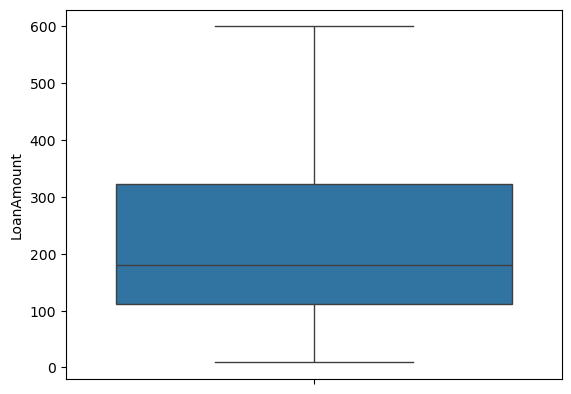

In [205]:
sns.boxplot(filtered_data.LoanAmount)

In [206]:
loan_data.LoanAmount.fillna(filtered_data.LoanAmount.mean(), inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\804001552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data.LoanAmount.fillna(filtered_data.LoanAmount.mean(), inplace= True)


In [207]:
loan_data.Loan_Amount_Term.isna().sum()

np.int64(14)

In [208]:
loan_data.Loan_Amount_Term.unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [209]:
clean_data = loan_data[~(loan_data.Loan_Amount_Term.isna())]

In [210]:
lb, ub = detect_outlier(clean_data.Loan_Amount_Term)

In [211]:
filtered_data = loan_data[(loan_data.Loan_Amount_Term>= lb) & (loan_data.Loan_Amount_Term<= ub)]

<Axes: ylabel='Loan_Amount_Term'>

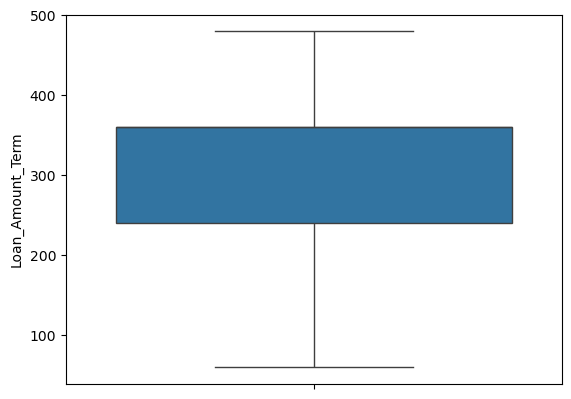

In [212]:
sns.boxplot(filtered_data.Loan_Amount_Term)

In [213]:
loan_data.Loan_Amount_Term.fillna(filtered_data.Loan_Amount_Term.median(), inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\2559606268.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data.Loan_Amount_Term.fillna(filtered_data.Loan_Amount_Term.median(), inplace= True)


In [214]:
loan_data.Credit_History.isna().sum()

np.int64(50)

In [215]:
loan_data.Credit_History.unique()

array([ 1.,  0., nan])

In [216]:
loan_data.Credit_History.fillna(loan_data.Credit_History.mode()[0], inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\2572634463.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data.Credit_History.fillna(loan_data.Credit_History.mode()[0], inplace= True)


In [217]:
loan_data.Property_Area.isna().sum()

np.int64(0)

In [218]:
loan_data.Property_Area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [219]:
loan_data.Loan_Status.isna().sum()

np.int64(0)

In [220]:
loan_data.Loan_Status.unique()

array(['Y', 'N'], dtype=object)

In [221]:
loan_data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,No,0,Graduate,No,5849,0.0,218.272956,360.0,1.0,Urban,Y
1,LP000002,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP000003,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP000004,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP000005,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


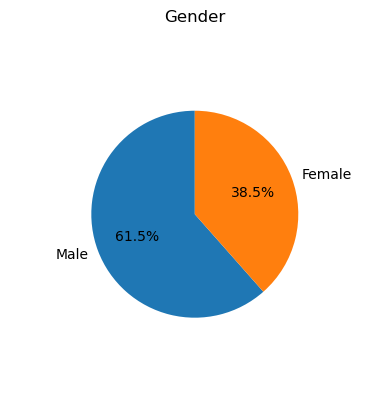

In [222]:
plt.pie(loan_data.Gender.value_counts(), labels= loan_data.Gender.value_counts().index,
       autopct= "%1.1f%%", startangle= 90, radius= 0.7)
plt.title('Gender')
plt.show()

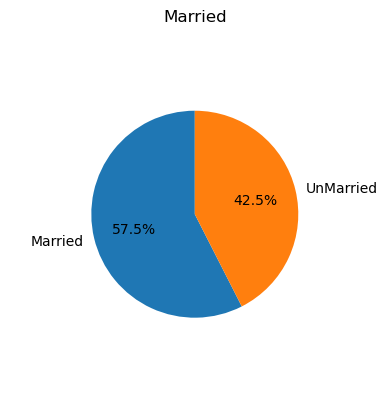

In [223]:
plt.pie(loan_data.Married.value_counts(), labels=["Married", "UnMarried"],
       autopct= "%1.1f%%", startangle= 90, radius= 0.7)
plt.title("Married")
plt.show()

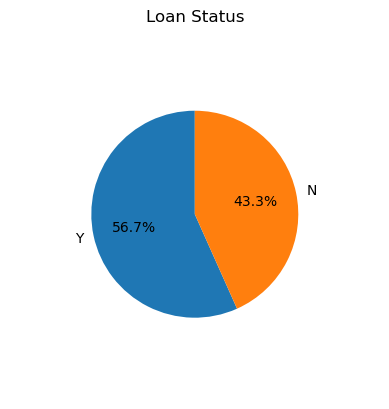

In [224]:
plt.pie(loan_data.Loan_Status.value_counts(), labels= loan_data.Loan_Status.value_counts().index,
       autopct= "%1.1f%%", startangle= 90, radius= 0.7)
plt.title("Loan Status")
plt.show()

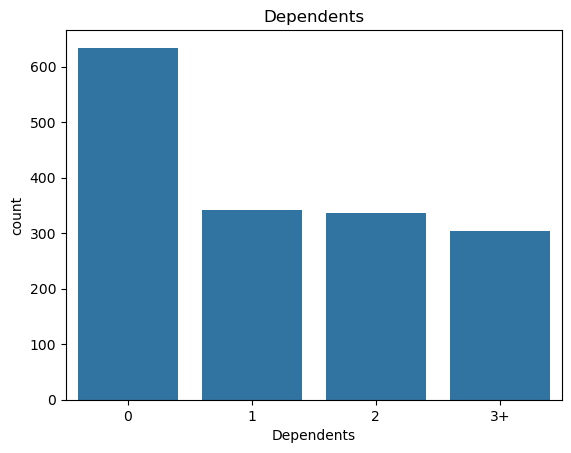

In [225]:
sns.countplot(loan_data, x= 'Dependents', order= loan_data['Dependents'].value_counts().index)
plt.title('Dependents')
plt.show()

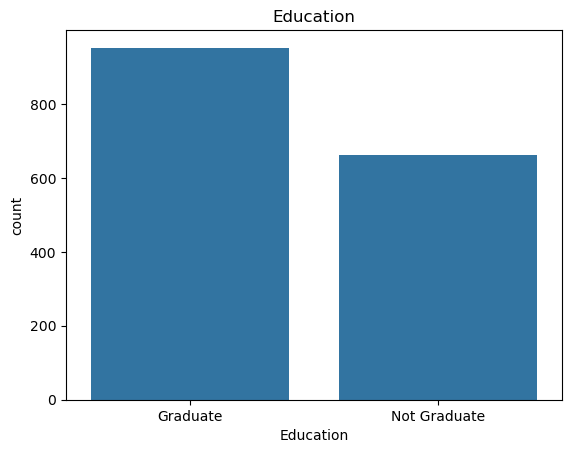

In [226]:
sns.countplot(loan_data, x= 'Education', order= loan_data['Education'].value_counts().index)
plt.title("Education")
plt.show()

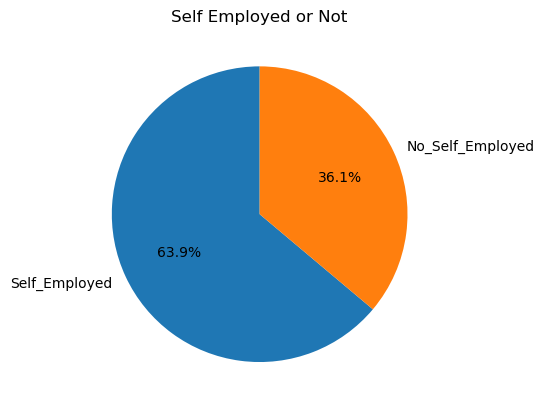

In [227]:
plt.pie(loan_data.Self_Employed.value_counts(), labels= ['Self_Employed', 'No_Self_Employed'],
       autopct= '%1.1f%%', startangle= 90)
plt.title("Self Employed or Not")
plt.show()

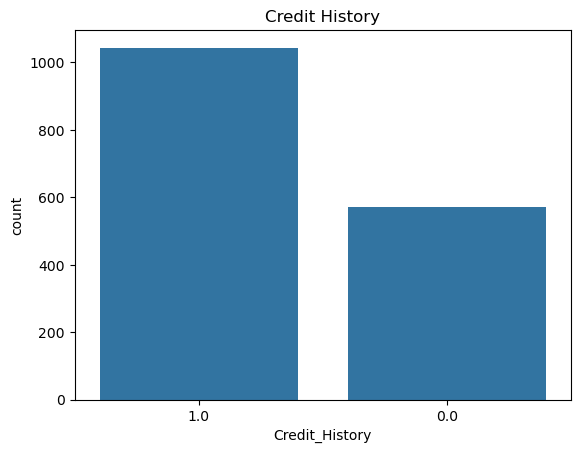

In [228]:
sns.countplot(loan_data, x= 'Credit_History', order= loan_data['Credit_History'].value_counts().index)
plt.title('Credit History')
plt.show()

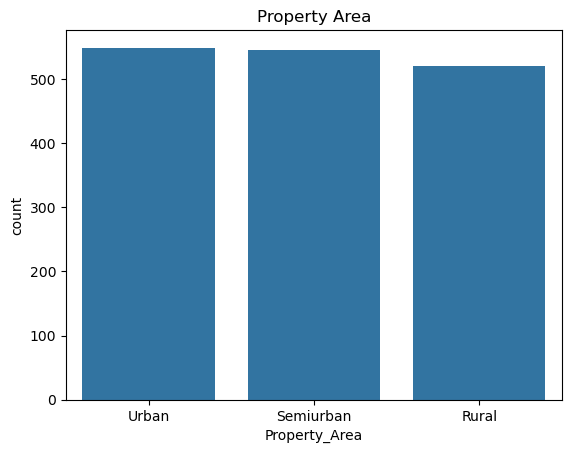

In [229]:
sns.countplot(loan_data, x= 'Property_Area', order= loan_data['Property_Area'].value_counts().index)
plt.title('Property Area')
plt.show()

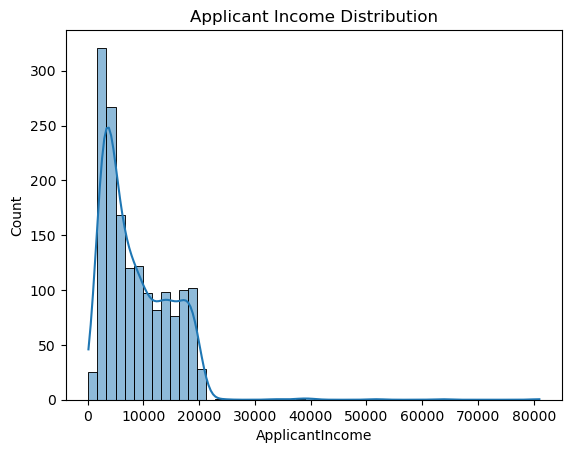

In [230]:
sns.histplot(loan_data, x= 'ApplicantIncome', kde= True)
plt.title('Applicant Income Distribution')
plt.show()

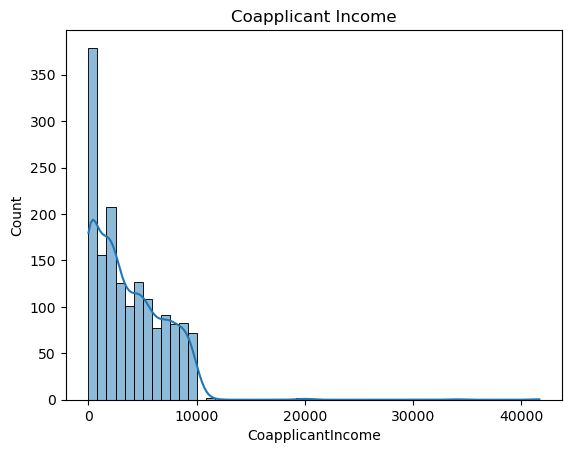

In [231]:
sns.histplot(loan_data, x= 'CoapplicantIncome', kde= True)
plt.title('Coapplicant Income')
plt.show()

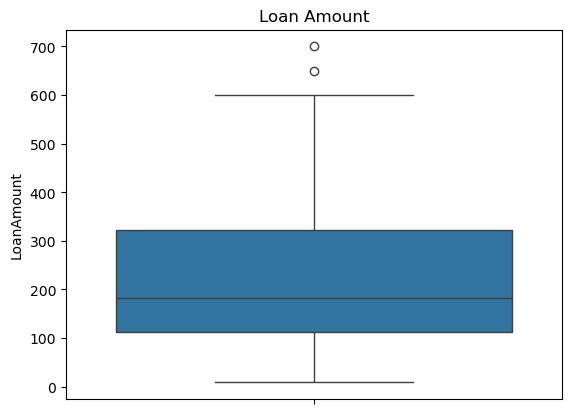

In [232]:
sns.boxplot(loan_data.LoanAmount)
plt.title('Loan Amount')
plt.show()

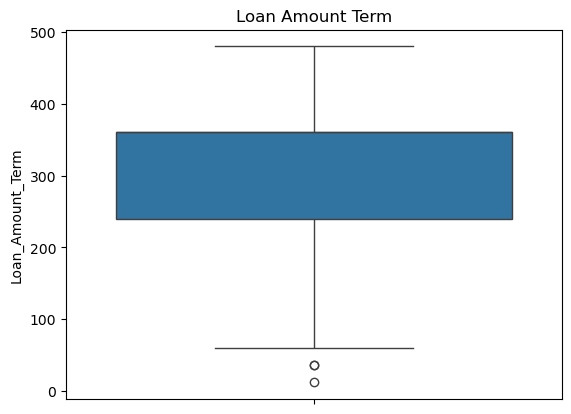

In [233]:
sns.boxplot(loan_data.Loan_Amount_Term)
plt.title('Loan Amount Term')
plt.show()

In [234]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1614 non-null   object 
 2   Married            1614 non-null   object 
 3   Dependents         1614 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1614 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1614 non-null   float64
 9   Loan_Amount_Term   1614 non-null   float64
 10  Credit_History     1614 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [235]:
adult_data = pd.read_csv('adult.csv')
adult_data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [236]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [237]:
adult_data.duplicated().sum()

np.int64(52)

In [238]:
adult_data.drop_duplicates(inplace= True)

In [239]:
adult_data.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [240]:
adult_data.age.isna().sum()

np.int64(0)

In [241]:
adult_data.age.unique()

array([25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20,
       37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30,
       47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77,
       80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85,
       76, 84, 89, 88, 87, 86])

<Axes: ylabel='age'>

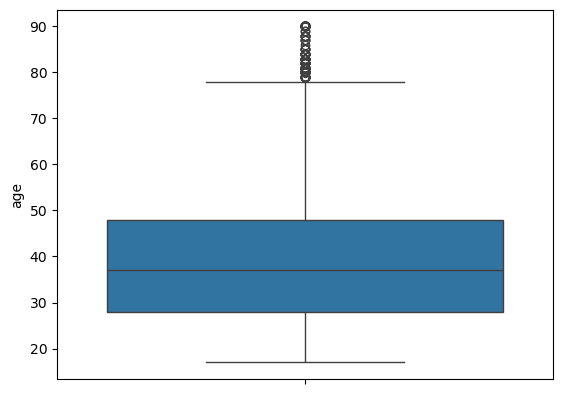

In [242]:
sns.boxplot(adult_data.age)

In [243]:
lb, ub = detect_outlier(adult_data.age)

In [244]:
adult_data['age'] = np.where(adult_data['age'] > ub, ub, adult_data['age'])

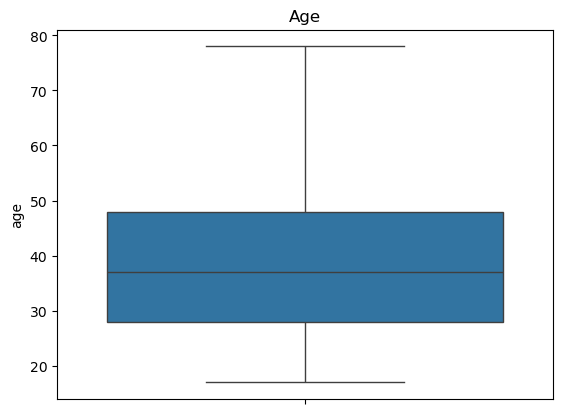

In [245]:
sns.boxplot(adult_data.age)
plt.title('Age')
plt.show()

In [246]:
adult_data.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [247]:
adult_data.workclass.unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [248]:
adult_data.workclass.mode()

0    Private
Name: workclass, dtype: object

In [249]:
adult_data.workclass.replace('?', adult_data['workclass'].mode()[0], inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\2522182161.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data.workclass.replace('?', adult_data['workclass'].mode()[0], inplace= True)


In [250]:
adult_data.fnlwgt.unique()

array([226802,  89814, 336951, ..., 129912, 255835, 257302],
      shape=(28523,))

In [251]:
fnlwgt_bins = [0, 100000, 200000, adult_data['fnlwgt'].max()]
fnlwgt_labels = ['Low Weight', 'Medium Weight', 'High Weight']
adult_data['fnlwgt_group'] = pd.cut(adult_data['fnlwgt'], bins= fnlwgt_bins, labels= fnlwgt_labels)
adult_data.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,fnlwgt_group
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,High Weight
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Low Weight
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,High Weight


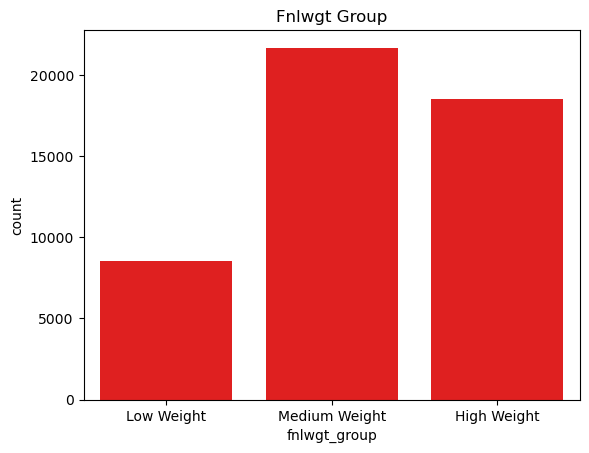

In [252]:
sns.countplot(adult_data, x= 'fnlwgt_group', color= 'red')
plt.title('Fnlwgt Group')
plt.show()

In [253]:
adult_data.education.unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

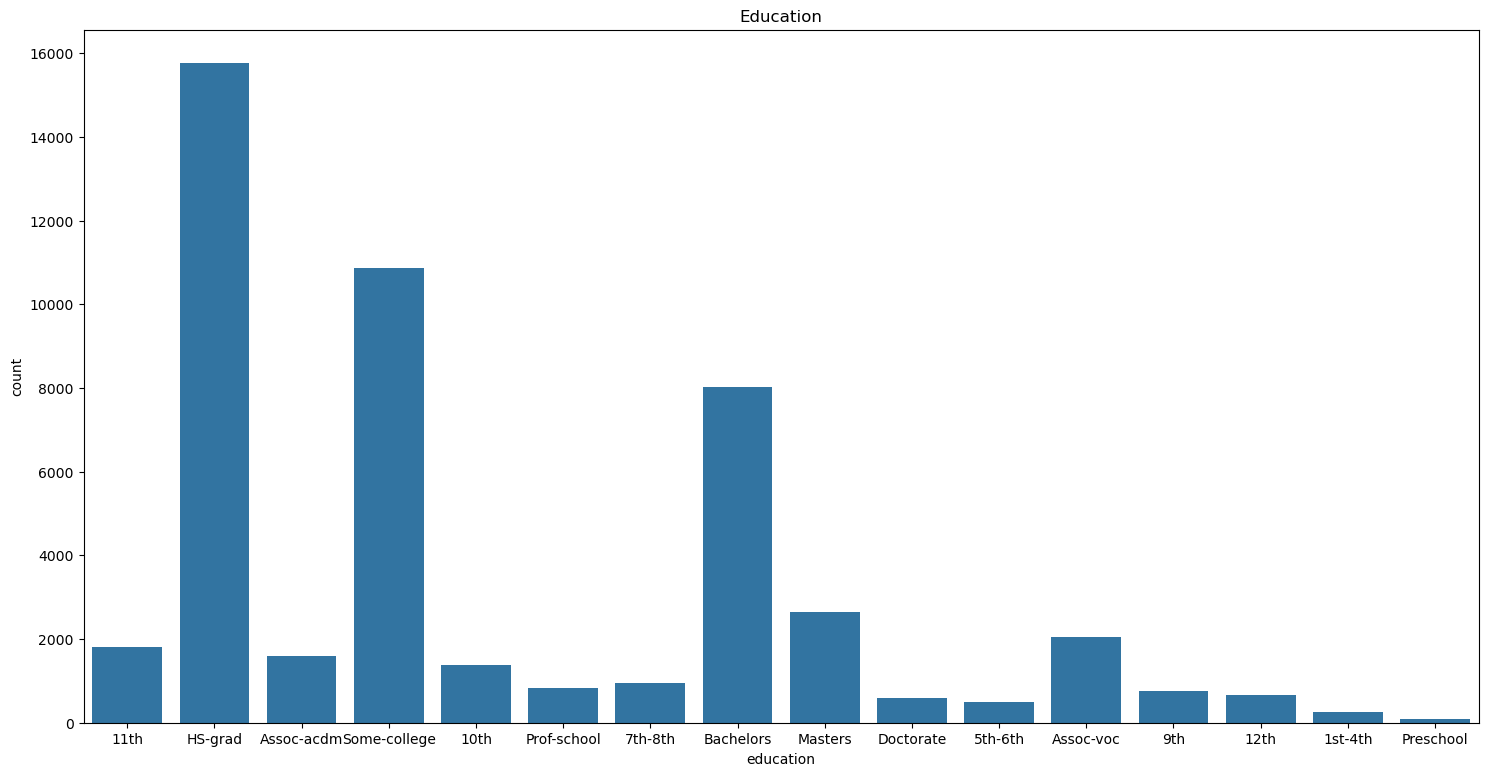

In [254]:
plt.figure(figsize=(18, 9))
sns.countplot(adult_data, x= 'education')
plt.title('Education')
plt.show()

In [255]:
adult_data['educational-num'].unique()

array([ 7,  9, 12, 10,  6, 15,  4, 13, 14, 16,  3, 11,  5,  8,  2,  1])

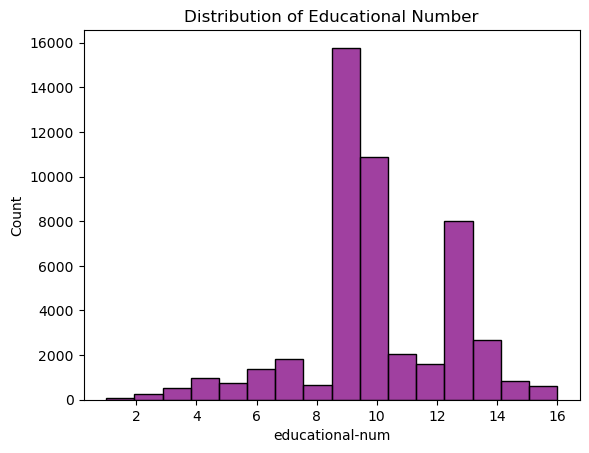

In [256]:
sns.histplot(adult_data, x= 'educational-num', bins= 16, color= 'purple')
plt.title('Distribution of Educational Number')
plt.show()

In [257]:
adult_data.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,fnlwgt_group
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,High Weight
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Low Weight
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,High Weight


In [258]:
adult_data['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

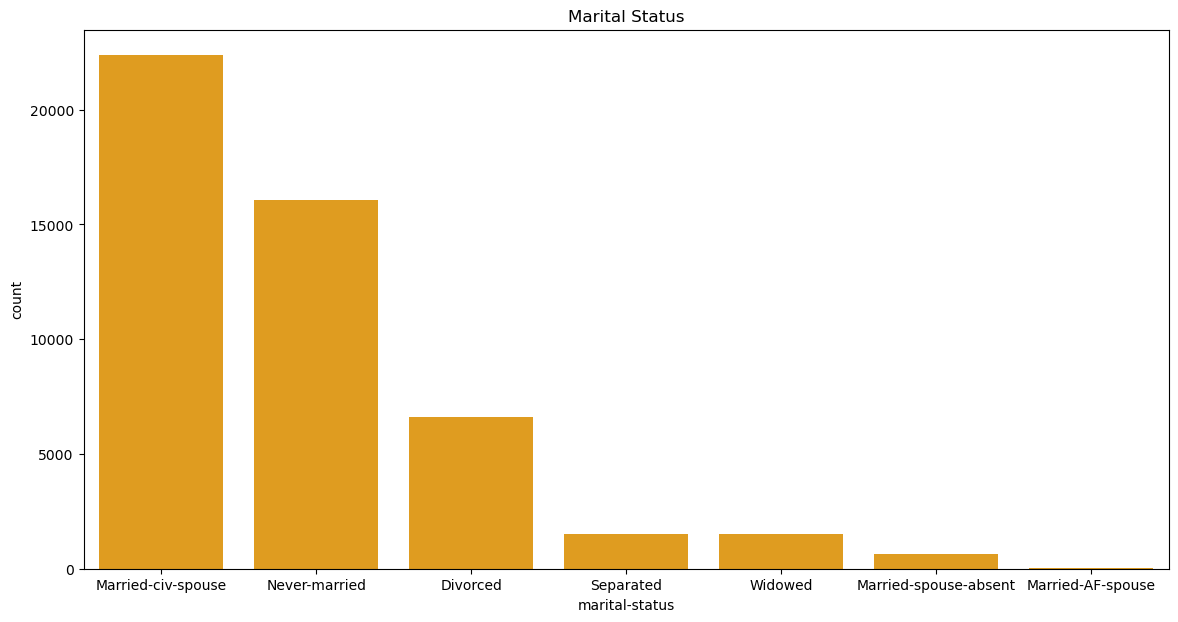

In [259]:
marital_counts = adult_data['marital-status'].value_counts().reset_index()
plt.figure(figsize= (14, 7))
sns.barplot(marital_counts, x= 'marital-status', y= 'count', color= 'orange')
plt.title('Marital Status')
plt.show()

In [260]:
adult_data.occupation.unique()

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object)

In [261]:
adult_data.occupation.replace('?', adult_data.occupation.mode()[0], inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\1108466968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data.occupation.replace('?', adult_data.occupation.mode()[0], inplace= True)


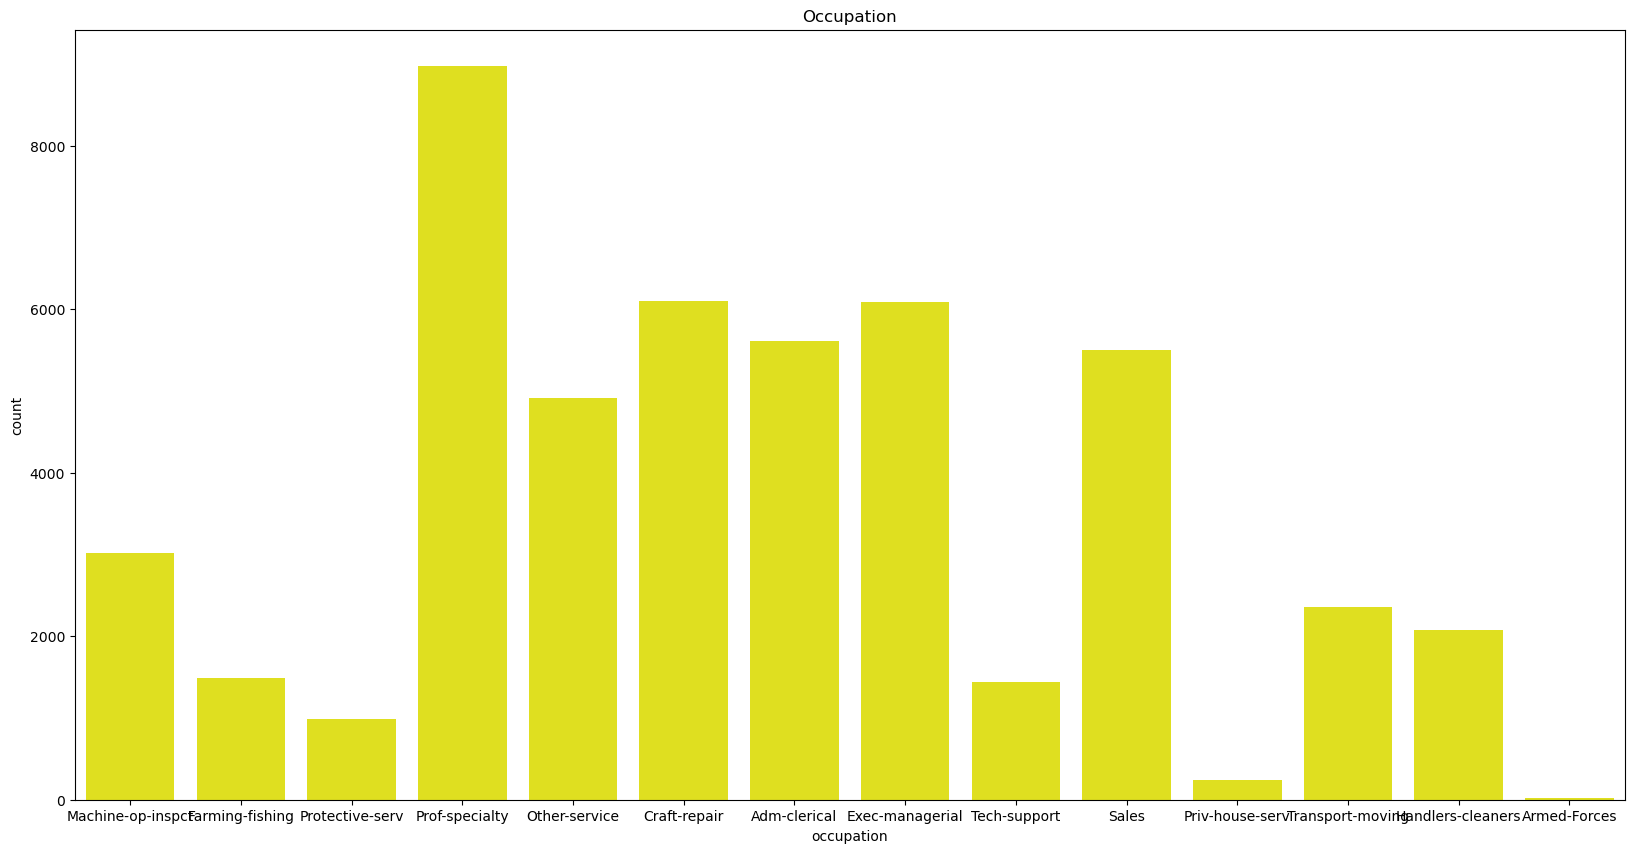

In [262]:
plt.figure(figsize= (20, 10))
sns.countplot(adult_data, x= 'occupation', color= 'yellow')
plt.title('Occupation')
plt.show()

In [263]:
adult_data.relationship.unique()

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

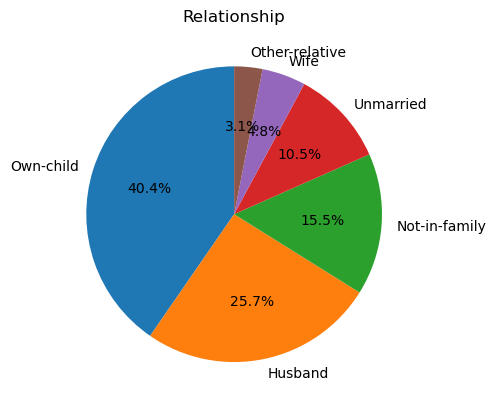

In [264]:
plt.pie(adult_data.relationship.value_counts(), labels= ['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], autopct= '%1.1f%%', startangle= 90, radius= 1)
plt.title('Relationship')
plt.show()

In [265]:
adult_data.race.unique()

array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

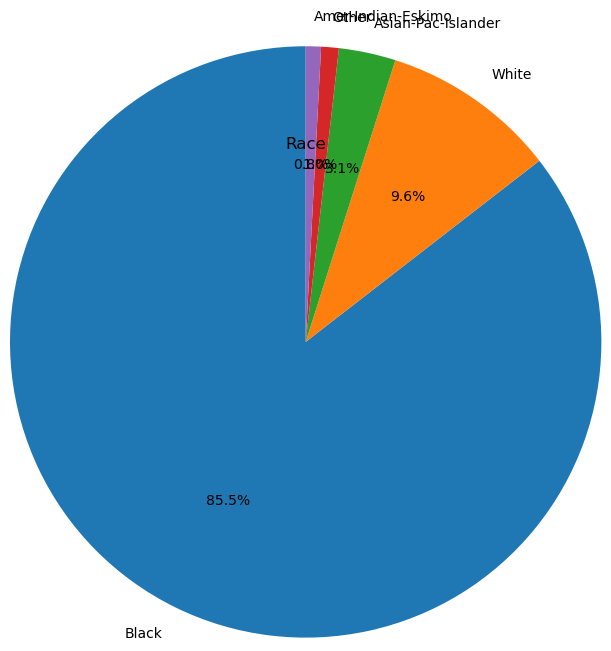

In [266]:
plt.pie(adult_data.race.value_counts(), labels=['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], autopct= '%1.1f%%', startangle= 90, radius=2)
plt.title('Race')
plt.show()

In [267]:
adult_data.gender.unique()

array(['Male', 'Female'], dtype=object)

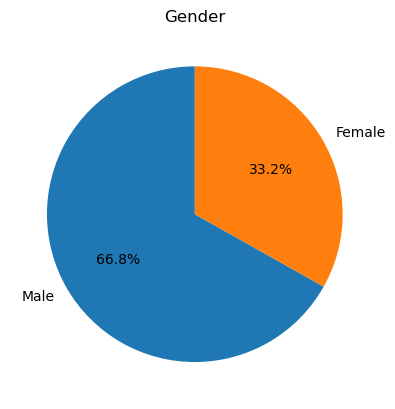

In [268]:
plt.pie(adult_data.gender.value_counts(), labels=['Male', 'Female'], autopct= '%1.1f%%', startangle= 90, radius=1)
plt.title('Gender')
plt.show()

In [269]:
adult_data['capital-gain'].unique()

array([    0,  7688,  3103,  6418,  7298,  3908, 14084,  5178, 15024,
       99999,  2597,  2907,  4650,  6497,  1055,  5013, 27828,  4934,
        4064,  3674,  2174, 10605,  3418,   114,  2580,  3411,  4508,
        4386,  8614, 13550,  6849,  2463,  3137,  2885,  2964,  1471,
       10566,  2354,  1424,  1455,  3325,  4416, 25236,   594,  2105,
        4787,  2829,   401,  4865,  1264,  1506, 10520,  3464,  2653,
       20051,  4101,  1797,  2407,  3471,  1086,  1848, 14344,  1151,
        2993,  2290, 15020,  9386,  2202,  3818,  2176,  5455, 11678,
        7978,  7262,  6514, 41310,  3456,  7430,  2414,  2062, 34095,
        1831,  6723,  5060, 15831,  2977,  2346,  3273,  2329,  9562,
        2635,  4931,  1731,  6097,   914,  7896,  5556,  1409,  3781,
        3942,  2538,  3887, 25124,  7443,  5721,  1173,  4687,  6612,
        6767,  2961,   991,  2036,  2936,  2050,  1111,  2228, 22040,
        3432,  6360,  2009,  1639, 18481,  2387])

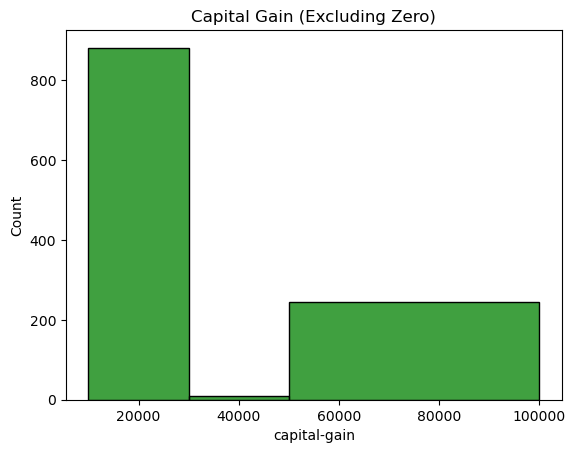

In [281]:
cg_bins = [10000, 30000, 50000, 100000]
filter_data = adult_data[adult_data['capital-gain'] > 0]
sns.histplot(filter_data['capital-gain'], bins= cg_bins, color= 'green')
plt.title('Capital Gain (Excluding Zero)')
plt.show()

In [271]:
adult_data['capital-loss'].unique()

array([   0, 1721, 1876, 2415, 1887,  625, 1977, 2057, 1429, 1590, 1485,
       2051, 2377, 1672, 1628, 1902, 1602, 1741, 2444, 1408, 2001, 2042,
       1740, 1825, 1848, 1719, 3004, 2179, 1573, 2205, 1258, 2339, 1726,
       2258, 1340, 1504, 2559, 1668, 1974, 1980, 1564, 2547, 2002, 1669,
       1617,  323, 3175, 2472, 2174, 1579, 2129, 1510, 1735, 2282, 1870,
       1411, 1911, 1651, 1092, 1762, 2457, 2231, 2238,  653, 1138, 2246,
       2603, 2392, 1944, 1380, 2465, 1421, 3770, 1594,  213, 2149, 2824,
       1844, 2467, 2163, 1816, 1648, 2206, 2352,  419, 1539,  880,  810,
        974, 4356, 2489, 1755, 3683, 2267, 2080,  155, 3900, 2201, 2754])

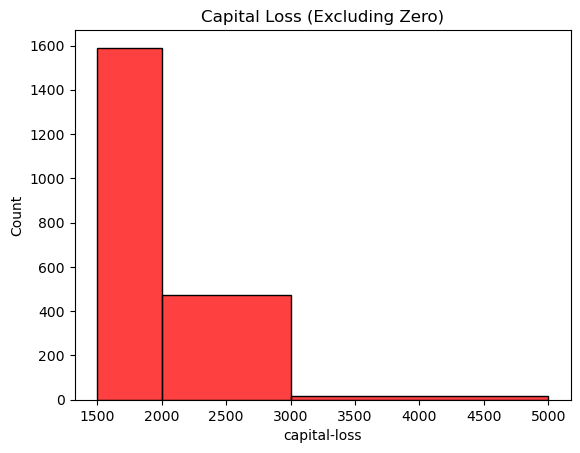

In [272]:
cl_bins = [1500, 2000, 3000, 5000]
filter_data = adult_data[adult_data['capital-loss'] > 0]
sns.histplot(filter_data['capital-loss'], bins= cl_bins, color= 'red')
plt.title('Capital Loss (Excluding Zero)')
plt.show()

In [273]:
adult_data['hours-per-week'].unique()

array([40, 50, 30, 32, 10, 39, 35, 48, 25, 20, 45, 47,  6, 43, 90, 54, 60,
       38, 36, 18, 24, 44, 56, 28, 16, 41, 22, 55, 14, 33, 37,  8, 12, 70,
       15, 75, 52, 84, 42, 80, 68, 99, 65,  5, 17, 72, 53, 29, 96, 21, 46,
        3,  1, 23, 49, 67, 76,  7,  2, 58, 26, 34,  4, 51, 78, 63, 31, 92,
       77, 27, 85, 13, 19, 98, 62, 66, 57, 11, 86, 59,  9, 64, 73, 61, 88,
       79, 89, 74, 69, 87, 97, 94, 82, 91, 81, 95])

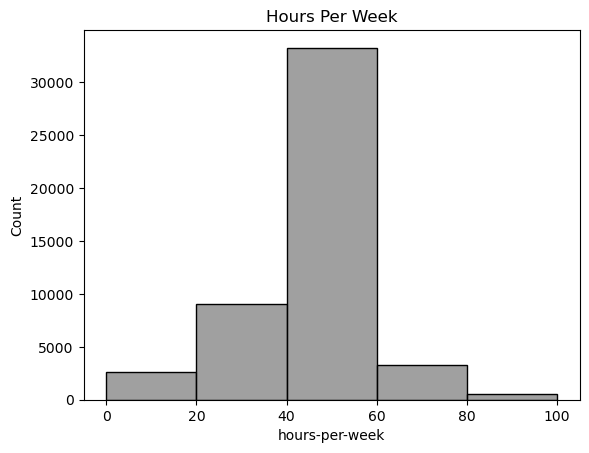

In [274]:
hpw_bins = [0, 20, 40, 60, 80, 100]
sns.histplot(adult_data['hours-per-week'], bins= hpw_bins, color= 'gray')
plt.title('Hours Per Week')
plt.show()

In [275]:
adult_data['native-country'].unique()

array(['United-States', '?', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

In [276]:
adult_data['native-country'].replace("?", adult_data['native-country'].mode()[0], inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_12916\1110770441.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data['native-country'].replace("?", adult_data['native-country'].mode()[0], inplace= True)


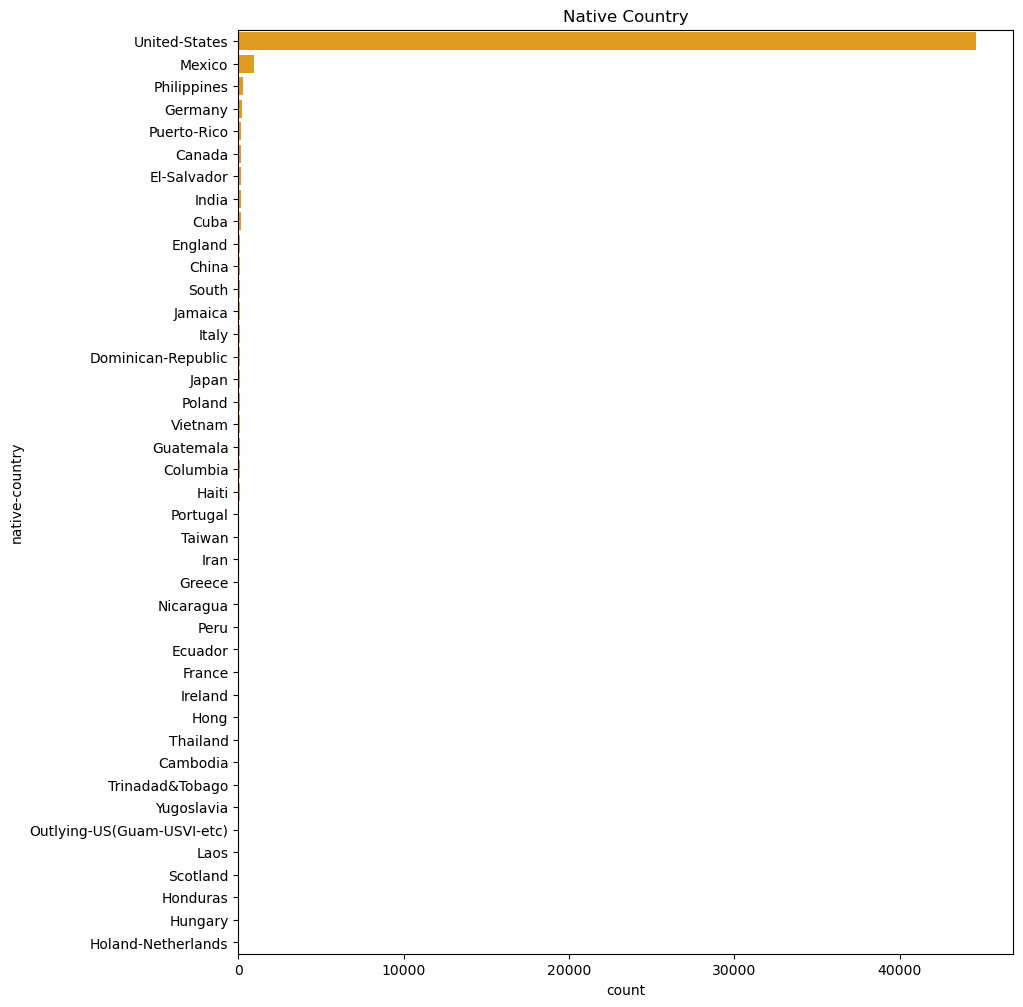

In [277]:
plt.figure(figsize= (10, 12))
sns.countplot(adult_data, y= 'native-country', color= 'orange',
              order= adult_data['native-country'].value_counts().index)
plt.title('Native Country')
plt.show()

In [278]:
adult_data.income.unique()

array(['<=50K', '>50K'], dtype=object)

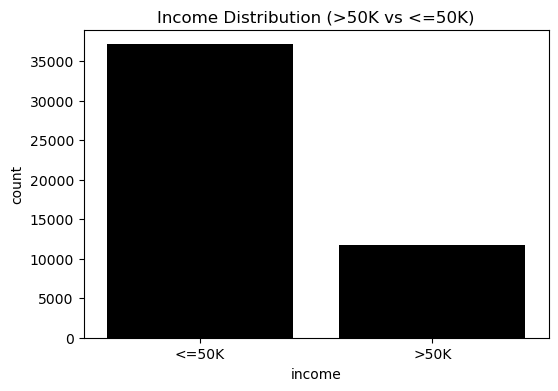

In [279]:
plt.figure(figsize=(6, 4))
sns.countplot(data=adult_data, x='income', color= 'black')
plt.title('Income Distribution (>50K vs <=50K)')
plt.show()

In [3]:
hotel_data = pd.read_csv('hotel_booking.csv')
hotel_data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


In [4]:
hotel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
hotel_data.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
hotel_data.duplicated().sum()

np.int64(0)

In [7]:
hotel_data.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734


In [8]:
hotel_data.hotel.unique()

array(['Resort Hotel', 'City Hotel'], dtype=object)

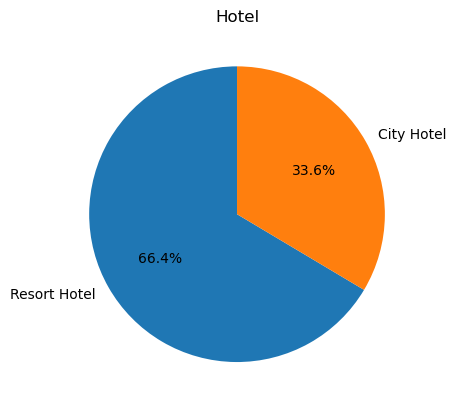

In [9]:
plt.pie(hotel_data.hotel.value_counts(), labels= ['Resort Hotel', 'City Hotel'],
       autopct= '%1.1f%%', startangle= 90)
plt.title('Hotel')
plt.show()

In [10]:
hotel_data.is_canceled.replace([0,1], ['No', 'Yes'], inplace= True)

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_7800\3906457533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hotel_data.is_canceled.replace([0,1], ['No', 'Yes'], inplace= True)


In [11]:
hotel_data.is_canceled.unique()

array(['No', 'Yes'], dtype=object)

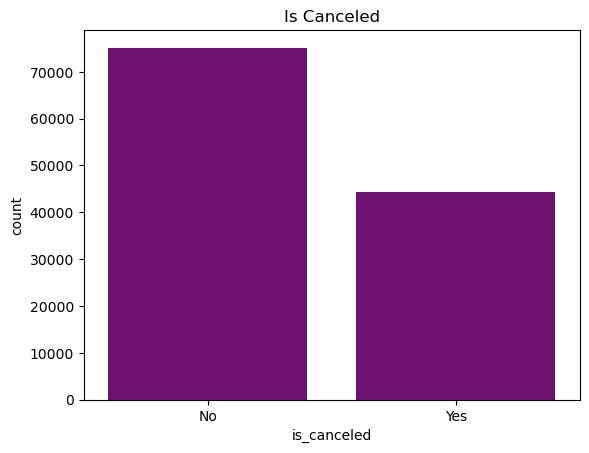

In [12]:
count_df = hotel_data.is_canceled.value_counts().reset_index()
sns.barplot(count_df, x= 'is_canceled', y= 'count', color= 'purple')
plt.title('Is Canceled')
plt.show()

In [13]:
hotel_data.lead_time.unique()

array([342, 737,   7,  13,  14,   0,   9,  85,  75,  23,  35,  68,  18,
        37,  12,  72, 127,  78,  48,  60,  77,  99, 118,  95,  96,  69,
        45,  40,  15,  36,  43,  70,  16, 107,  47, 113,  90,  50,  93,
        76,   3,   1,  10,   5,  17,  51,  71,  63,  62, 101,   2,  81,
       368, 364, 324,  79,  21, 109, 102,   4,  98,  92,  26,  73, 115,
        86,  52,  29,  30,  33,  32,   8, 100,  44,  80,  97,  64,  39,
        34,  27,  82,  94, 110, 111,  84,  66, 104,  28, 258, 112,  65,
        67,  55,  88,  54, 292,  83, 105, 280, 394,  24, 103, 366, 249,
        22,  91,  11, 108, 106,  31,  87,  41, 304, 117,  59,  53,  58,
       116,  42, 321,  38,  56,  49, 317,   6,  57,  19,  25, 315, 123,
        46,  89,  61, 312, 299, 130,  74, 298, 119,  20, 286, 136, 129,
       124, 327, 131, 460, 140, 114, 139, 122, 137, 126, 120, 128, 135,
       150, 143, 151, 132, 125, 157, 147, 138, 156, 164, 346, 159, 160,
       161, 333, 381, 149, 154, 297, 163, 314, 155, 323, 340, 35

In [14]:
hotel_data.lead_time.min()

0

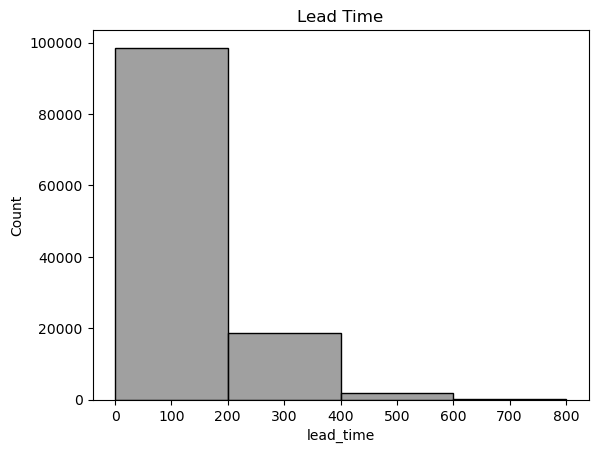

In [15]:
lt_bins = [0, 200, 400, 600, 800]
sns.histplot(hotel_data.lead_time, bins= lt_bins, color= 'gray')
plt.title('Lead Time')
plt.show()

In [16]:
hotel_data.arrival_date_year.unique()

array([2015, 2016, 2017])

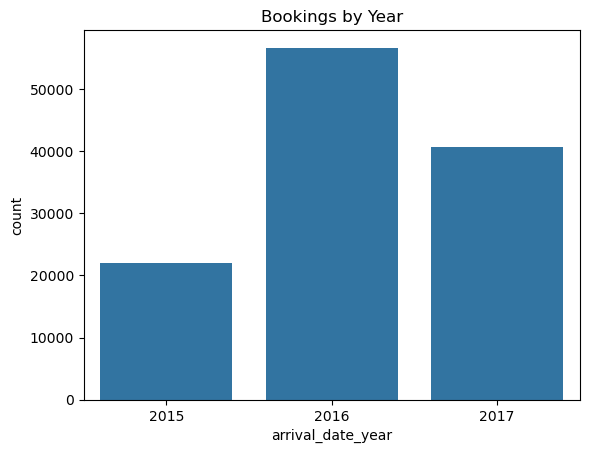

In [17]:
sns.countplot(hotel_data, x= 'arrival_date_year')
plt.title('Bookings by Year')
plt.show()

In [18]:
hotel_data.arrival_date_month.unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [19]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
hotel_data['arrival_date_month'] = pd.Categorical(hotel_data.arrival_date_month, categories= month_order, ordered= True)

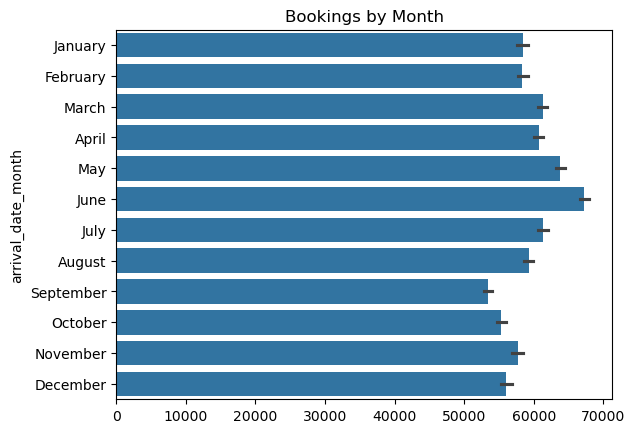

In [20]:
sns.barplot(hotel_data.arrival_date_month)
plt.title('Bookings by Month')
plt.show()

In [21]:
hotel_data.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,No,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,No,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,No,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734


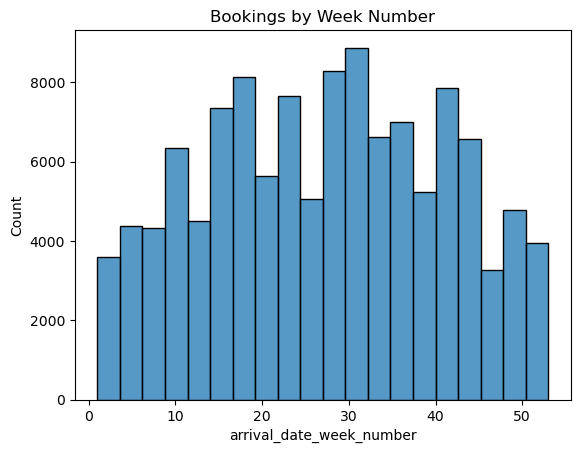

In [22]:
sns.histplot(hotel_data, x= 'arrival_date_week_number', bins= 20)
plt.title('Bookings by Week Number')
plt.show()

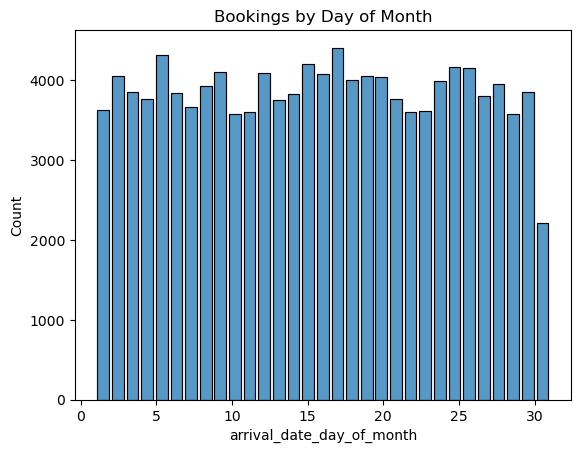

In [23]:
sns.histplot(data=hotel_data, x='arrival_date_day_of_month', bins=31, shrink= 0.8)
plt.title('Bookings by Day of Month')
plt.show()

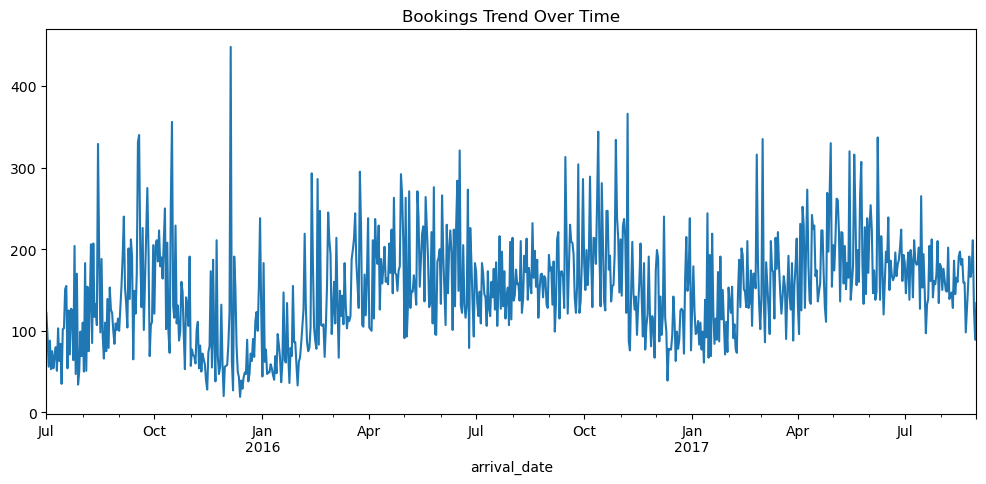

In [24]:
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
hotel_data['month_num'] = hotel_data.arrival_date_month.map(month_map)
hotel_data['arrival_date'] = pd.to_datetime(dict(year = hotel_data.arrival_date_year,
                                                month = hotel_data.month_num,
                                                day = hotel_data.arrival_date_day_of_month))
hotel_data['arrival_date'].value_counts().sort_index().plot(kind='line', figsize=(12, 5))
plt.title('Bookings Trend Over Time')
plt.show()

In [25]:
hotel_data.stays_in_weekend_nights.unique()

array([ 0,  1,  2,  4,  3,  6, 13,  8,  5,  7, 12,  9, 16, 18, 19, 10, 14])

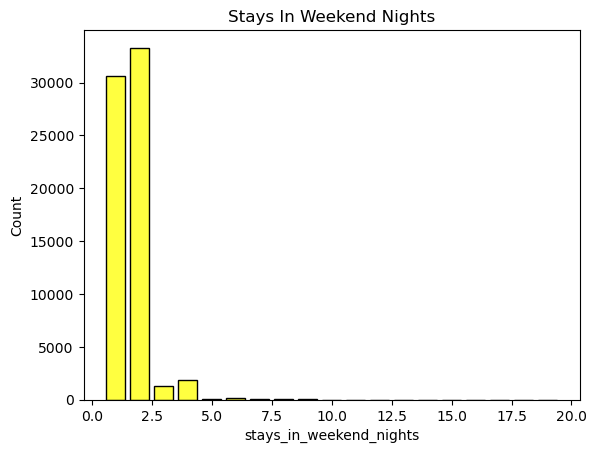

In [26]:
filtered_data = hotel_data[hotel_data.stays_in_weekend_nights > 0]
sns.histplot(filtered_data, x= 'stays_in_weekend_nights', color= 'yellow', discrete= True, shrink= 0.8)
plt.title('Stays In Weekend Nights')
plt.show()

In [27]:
hotel_data.stays_in_week_nights.unique()

array([ 0,  1,  2,  3,  4,  5, 10, 11,  8,  6,  7, 15,  9, 12, 33, 20, 14,
       16, 21, 13, 30, 19, 24, 40, 22, 42, 50, 25, 17, 32, 26, 18, 34, 35,
       41])

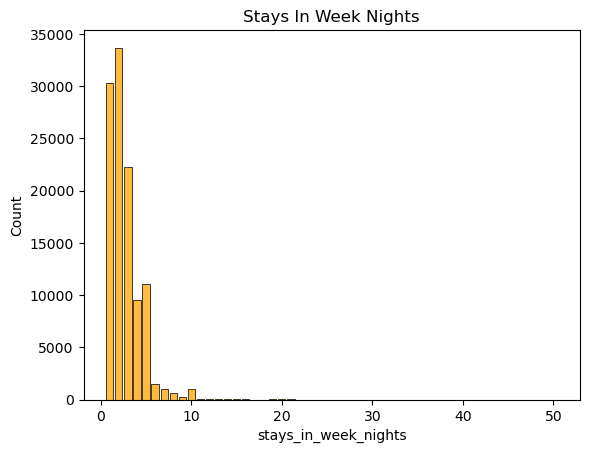

In [28]:
filtered_data = hotel_data[hotel_data.stays_in_week_nights > 0]
sns.histplot(filtered_data, x= 'stays_in_week_nights', color= 'orange', discrete= True, shrink= 0.8)
plt.title('Stays In Week Nights')
plt.show()

In [29]:
hotel_data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card', 'month_num', 'arrival_date'],
      dtype='object')

In [30]:
hotel_data.adults.unique()

array([ 2,  1,  3,  4, 40, 26, 50, 27, 55,  0, 20,  6,  5, 10])

In [31]:
lb, ub = detect_outlier(hotel_data.adults)

In [32]:
adult_mean = hotel_data.loc[(hotel_data['adults'] >= lb) & (hotel_data['adults'] <= ub), 'adults'].mean()
adult_mean

np.float64(2.0)

In [33]:
hotel_data.loc[(hotel_data['adults']< lb) | (hotel_data['adults']>ub), 'adults'] = adult_mean

<Axes: xlabel='adults', ylabel='count'>

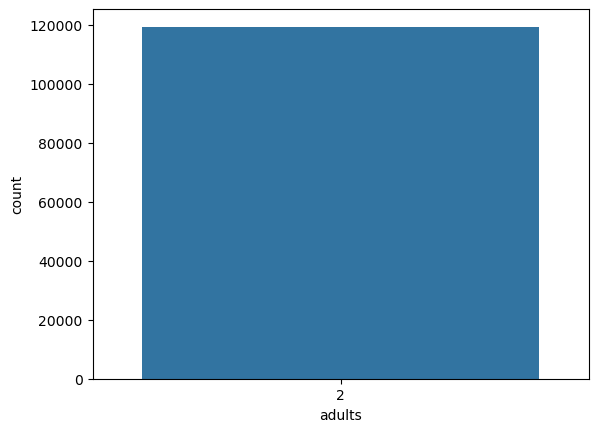

In [34]:
sns.countplot(hotel_data, x= 'adults')

In [35]:
hotel_data.children.isna().sum()

np.int64(4)

In [36]:
hotel_data.children.unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [37]:
chil_max = hotel_data[hotel_data.children <= 5]['children'].max()
hotel_data.children.fillna(chil_max, inplace= True)
hotel_data.loc[hotel_data['children'] > 5, 'children'] = 3.0

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_7800\3568328365.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hotel_data.children.fillna(chil_max, inplace= True)
